# **California Housing Price Prediction**

## **Objective:**
The goal of this assignment is to practice working with real-world data using basic Pandas methods and performing linear regression using Scikit-Learn. You will predict housing prices based on various features from the California housing dataset.

* Details about this Dataset can be [found on Kaggle.](https://www.kaggle.com/datasets/camnugent/california-housing-prices)
  - Unlike the example you worked on in class, i.e., the Advertising dataset, you will not be importing the dataset as a CSV file. Instead, this homework will show you how to **download the dataset directly from Scikit-Learn.**  
* In short, the dataset contains information from the 1990 California census.
* So although it may not help you with predicting current housing prices like the [Zillow Zestimate dataset](https://www.kaggle.com/competitions/zillow-prize-1), (which is a much harder dataset to work with) it does provide an accessible introductory dataset to get your hands dirty about the basics of data analysis using Scikit-learn.
* Reference: Pace, R. Kelley, and Ronald Barry. "*Sparse spatial autoregressions.*" Statistics & Probability Letters 33.3 (1997): 291-297 ([link to paper](https://spatial-statistics.com/pace_manuscripts/spletters_ms_dir/statistics_prob_lets/html/ms_sp_lets1.html))
  - From Sec. B (titled "Data") of the paper:  *"We collected information on the variables using all the block groups in California from the 1990 Census. In this sample a block group on average includes 1425.5 individuals living in a geographically compact area. Naturally, the geographical area included varies inversely with the population density. We computed distances among the centroids of each block group as measured in latitude and longitude. We excluded all the block groups reporting zero entries for the independent and dependent variables. The final data contained 20,640 observations on 9 variables."*

### Begin with standard imports.
```python
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
```

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

## Task 1: Downloading the dataset and converting to a Pandas DataFrame.
### **Download directly from Scikit-Learn**
- Again, notice that this is different from the method used in class (reading a <code>.csv</code> file on your machine as a Pandas DataFrame).
- Use the **California Housing Price dataset** from Scikit-Learn.
- You can load the dataset using the information available here:
  - https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html
  - Additional information: https://inria.github.io/scikit-learn-mooc/python_scripts/datasets_california_housing.html
  - Explain in your own words (a) what the `fetch_california_housing` method does, and (b) how the `as_frame=True` option can be used to produce a Pandas DataFrame (do you need to do anything extra after using the above method with the `as_frame` option?).
  - Does Scikit-Learn have any other example datasets? If yes, name two others. 

In [2]:
# Enter your code here

### **Task 2: Initial Exploration**
1. Print the first 3 rows of the DataFrame.
2. Print and study the features of the dataframe. What does each of the 8 features represent? Which column is the regression label? You may have to search the web for this information.
3. Check for null and non-null values.
4. How many unique values do the `Latitude` and `Longitude` features have?
5. The downloaded dataset has one column missing, viz, `ocean_proximity`.
   * This data has been provided as a separate `.csv` file. Read this file into a Pandas DataFrame.
   * Append this as a new column into your original DataFrame. Make sure to use the correct value for `axis` while appending (is it `axis=0` or `axis=1`?).
   * Finally, `ocean_proximity` values need to be converted into numerical values before they can be used for regression. Given the following dictionary, what Pandas command will you use to to convert `ocean_proximity` values into numerical values?
     ```python
     keys = df['ocean_proximity'].unique()
     values = range(len(keys))
     proximity_map = {keys[i]:values[i] for i in range(len(keys))}
     ```
6. Review your notes for Seaborn's `boxplot` method. Plot `ocean_proximity` vs `MedHouseVal`. What can you infer from this plot? Do house prices follow any discernable trend with respect to `ocean_proximity`?
7. Plot a jointplot of `MedInc` vs `MedHouseVal`. What general trend can you infer from this plot?
8. Create a separate DataFrame that contains only integer and floating point values. You might want to review the literature for the `DataFrame.info()` and `DataFrame.select_dtypes()` methods.

### Freddie Karlbom's blog.
https://freddiek.github.io/2018/02/25/california-housing-data-exploration.html

In [3]:
# BEFORE appending the ocean_proximity column, your DataFrame should look like this:

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521


In [4]:
# General information about the data types in each column.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [21]:
# AFTER appending the ocean proximity column and subsequently converting string values into integer values, your Data Frame should look like this:

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,ocean_proximity,proximity_numerical
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,NEAR BAY,0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,NEAR BAY,0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,NEAR BAY,0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,NEAR BAY,0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,NEAR BAY,0


<Axes: xlabel='ocean_proximity', ylabel='MedHouseVal'>

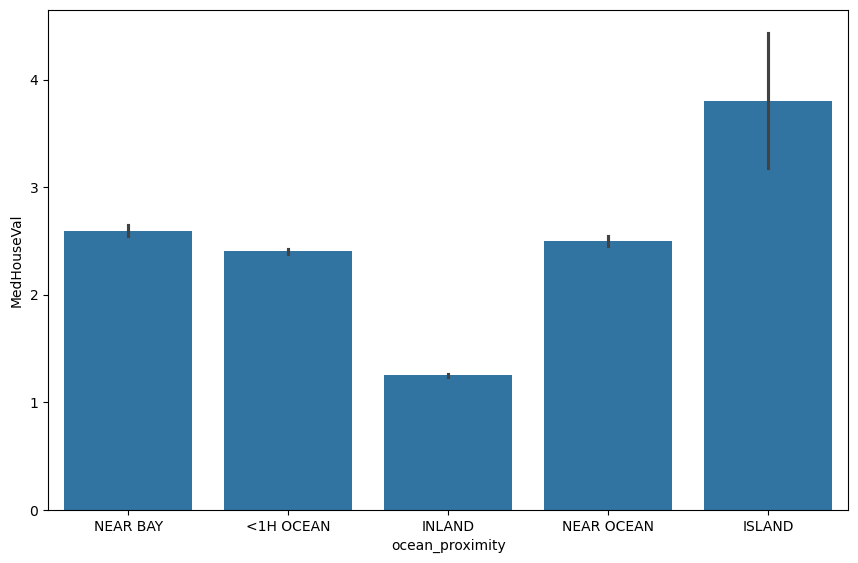

In [66]:
# The 'ocean_proximity' versus 'MedHouseVal' should look like this:

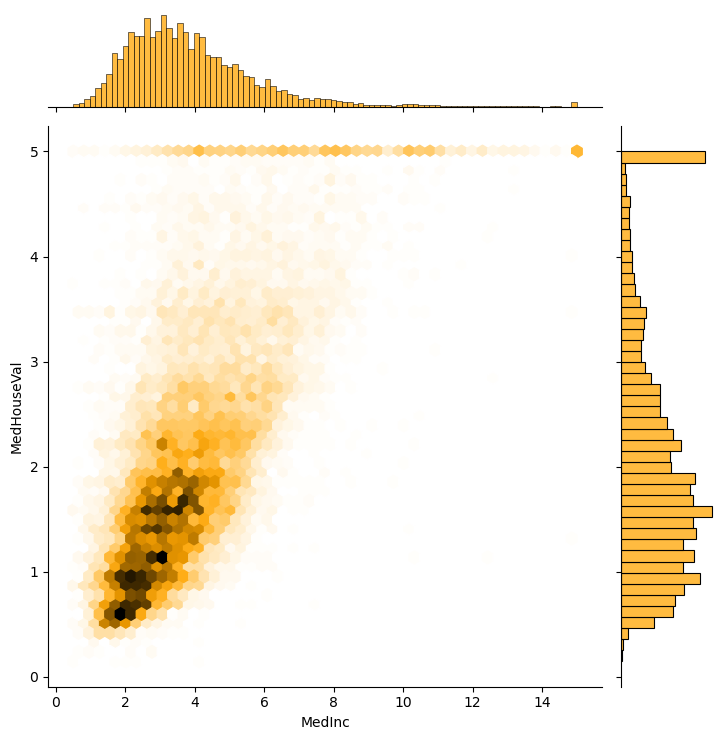

In [46]:
# The jointplot of 'MedInc' vs 'MedHouseVal' should look like this:

## **Task 3: Regression Analysis**
1. Split the DataFrame into a features DataFrame (`X`), and a labels Series (`y`). Be careful to include only numerical features at this stage!
2. Split the dataset into a training set and a test set. Set `random_state = 42`
3. From the `linear_model` module of Scikit-Learn, import `LinearRegression`
   * Create a linear regression object, and fit the object on the training data.
   * Generate predictions on the test data and report mean absolute error and root mean squared error for your model.
4. Create a scatter plot of test labels versus predicted labels.

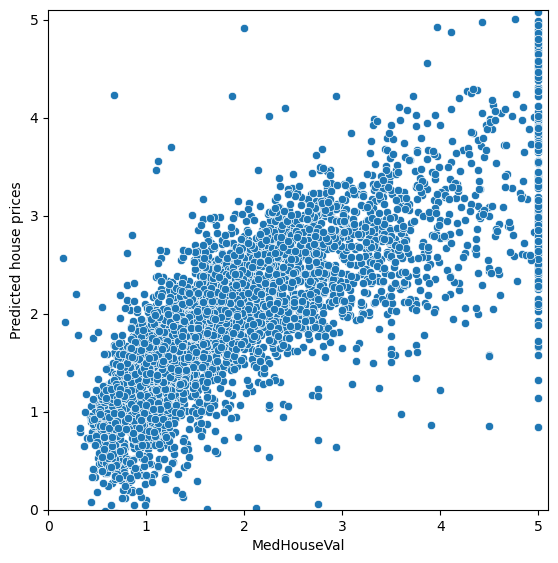

In [78]:
# The scatter plot of 'MedHouseVal' versus predicted labels should look like this: